In [ ]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ToyotaCorolla - MLR.csv to ToyotaCorolla - MLR.csv


In [ ]:
#load Dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

In [ ]:
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol,Age_08_04_KM
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False,1080678
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False,1677551
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False,1001064
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False,1248000
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False,1155000


In [ ]:
#Exploratory Data Analysis (EDA)
#1 Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [ ]:
#2 Summary Statistics
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [ ]:
#3 Check Missing Values
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


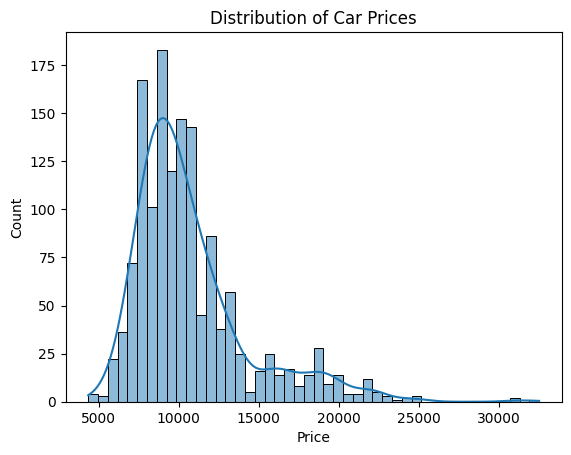

In [ ]:
#4 Distribution of Price
plt.figure()
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Car Prices")
plt.show()

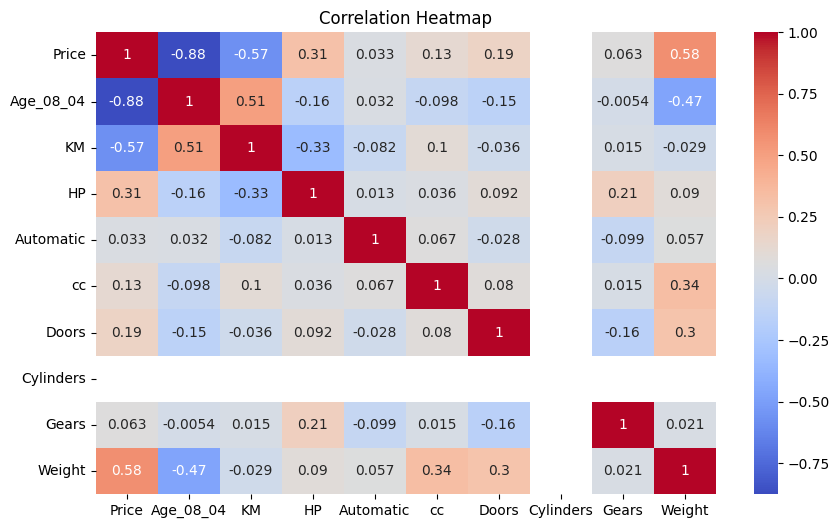

In [ ]:
#5 Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

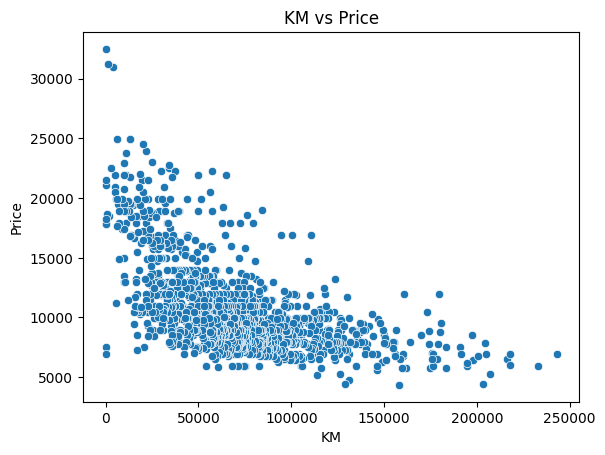

In [ ]:
#KM vs Price
sns.scatterplot(x='KM', y='Price', data=df)
plt.title("KM vs Price")
plt.show()

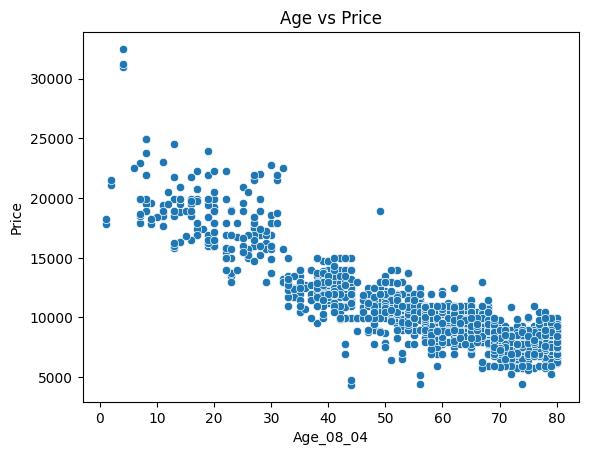

In [ ]:
#Age vs Price
sns.scatterplot(x='Age_08_04', y='Price', data=df)
plt.title("Age vs Price")
plt.show()

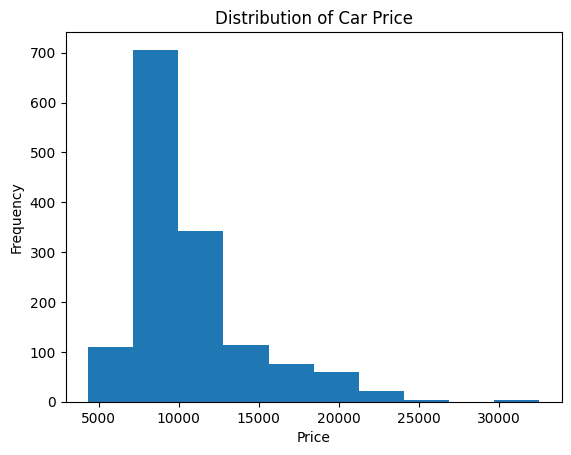

In [ ]:
plt.hist(df['Price'])
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Car Price")
plt.show()

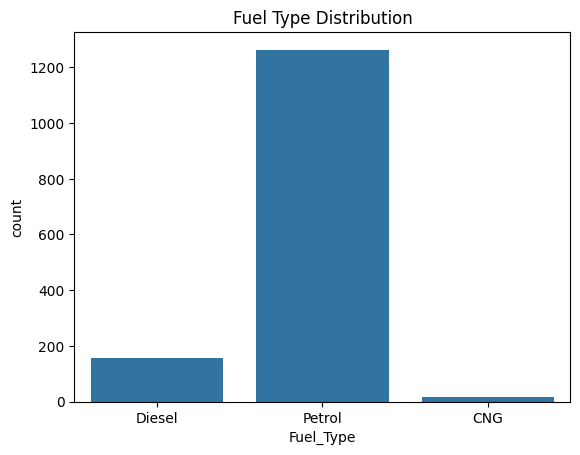

In [ ]:
#Fuel Type Distribution
sns.countplot(x='Fuel_Type', data=df)
plt.title("Fuel Type Distribution")
plt.show()

In [ ]:
#Data Pre-Processing
#FuelType converted into dummy variables
df = pd.get_dummies(df,columns=['Fuel_Type'], drop_first=True)

In [ ]:
#Feature & Target separation:
X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
#(2)Train – Test Split(80–20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#MODEL – Reduced Feature Model
X_reduced = df[['Age_08_04', 'KM', 'HP', 'Weight', 'Price']]

X = X_reduced.drop("Price", axis=1)
y = X_reduced["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred2))


R2 Score: 0.8506068681500834


In [ ]:
#MODEL– Polynomial Interaction
df['Age_08_04_KM'] = df['Age_08_04'] * df['KM']

X = df[['Age_08_04', 'KM', 'Age_08_04_KM', 'HP', 'Weight']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred3))


R2 Score: 0.871168239291176


In [ ]:
#Multiple Linear Regression
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

In [ ]:
#(3)check Coefficients
coeff = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
})
coeff

,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,-1.620037e-12
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


In [ ]:
#(4)Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred1)
rmse = np.sqrt(mean_squared_error(y_test, y_pred1))
mae = mean_absolute_error(y_test, y_pred1)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R2: 0.8348888040611082
RMSE: 1484.2654153296514
MAE: 990.8872739193926


In [ ]:
#Reduced Model
X_reduced = X[['Age_08_04','KM','HP','Weight']]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(Xr_train, yr_train)

LinearRegression()

In [ ]:
#(5)Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)

Ridge(alpha=1)

In [ ]:
#Lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

Interview que answer:
Normalization Scales data to a fixed range.
Standardization Centers data around mean with unit variance.
Essential for algorithms sensitive to scale -Ridge, Lasso, KNN.
Improves convergence and model stability.